# H2 Leak Prediction — Single Sensor Version

This notebook retrains the hydrogen leak prediction pipeline for a **single-sensor setup**.

It uses only these input features:

- `time (s)`
- `ppm`

To stay compatible with the original dataset structure, the notebook first creates a new `ppm` feature by averaging these four legacy sensor columns:

- `compressor sensor (ppm)`
- `storage sensor (ppm)`
- `pipeline sensor (ppm)`
- `fuelcell sensor (ppm)`

Then it:

- loads and cleans the dataset
- creates the single `ppm` feature
- trains one XGBoost model per target
- evaluates each model on validation/test splits
- plots feature importance
- plots confusion matrices
- saves the final trained bundle as a `.pkl`

## Predicted targets
- `leak severity`
- `action plan`

## Final model input at inference time

```python
{
    "time (s)": elapsed_seconds,
    "ppm": ppm
}
```

## Notes
- `leak location` was intentionally removed from the targets because the new deployment uses only one sensor.
- This notebook assumes the training Excel file still contains the original four sensor columns, and combines them into one `ppm` column for retraining.


## 0) Install dependencies

In [5]:
! pip install xgboost openpyxl joblib scikit-learn pandas matplotlib

In [6]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

## 1) Configuration

In [7]:
EXCEL_FILE = "/content/sample_data/H2-Dataset.xlsx"
DATA_SHEET = "Data"
DESC_SHEET = "Des."
OUTPUT_MODEL_FILE = "hydrogen_leakage_prediction_model_single_sensor.pkl"

RAW_SENSOR_COLUMNS = [
    "compressor sensor (ppm)",
    "storage sensor (ppm)",
    "pipeline sensor (ppm)",
    "fuelcell sensor (ppm)",
]

FEATURE_COLUMNS = [
    "time (s)",
    "ppm",
]

TARGET_COLUMNS = [
    "leak severity",
    "action plan",
]

TEST_SIZE = 0.20
RANDOM_STATE = 42
N_ITER_SEARCH = 10
CV_FOLDS = 3

## 2) Load the dataset

In [8]:
print("Loading Excel file...")
if not os.path.exists(EXCEL_FILE):
    raise FileNotFoundError(f"Excel file not found: {EXCEL_FILE}")

data_df = pd.read_excel(EXCEL_FILE, sheet_name=DATA_SHEET)

try:
    des_df = pd.read_excel(EXCEL_FILE, sheet_name=DESC_SHEET)
    print("Loaded 'Des.' sheet successfully.")
except Exception:
    des_df = None
    print("'Des.' sheet could not be loaded. Continuing without it.")

print("\nData shape:", data_df.shape)
display(data_df.head())

print("\nColumns:")
print(list(data_df.columns))

Loading Excel file...
Loaded 'Des.' sheet successfully.

Data shape: (13320, 10)


,time (s),leak_label,leak location,leak severity,action plan,phase,compressor sensor (ppm),storage sensor (ppm),pipeline sensor (ppm),fuelcell sensor (ppm)
0,0,0,none,none,none,normal,13.16,13.79,16.64,14.61
1,5,0,none,none,none,normal,15.52,11.49,19.05,17.50
2,10,0,none,none,none,normal,19.33,16.78,17.16,21.55
3,15,0,none,none,none,normal,15.85,18.86,13.33,12.04
4,20,0,none,none,none,normal,12.90,21.76,13.25,18.36



Columns:
['time (s)', 'leak_label', 'leak location', 'leak severity', 'action plan', 'phase', 'compressor sensor (ppm)', 'storage sensor (ppm)', 'pipeline sensor (ppm)', 'fuelcell sensor (ppm)']


## 3) Validate required columns for single-sensor training

In [9]:
required_raw_columns = list(set(RAW_SENSOR_COLUMNS + ["time (s)"] + TARGET_COLUMNS))
missing_columns = [col for col in required_raw_columns if col not in data_df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required raw columns are present.")

All required raw columns are present.


## 4) Build a single `ppm` feature and clean the data

In [10]:
df = data_df[required_raw_columns].copy()

for col in RAW_SENSOR_COLUMNS + ["time (s)"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert the four old sensor columns into one single-sensor feature.
# You can replace mean() with another rule later if needed.
df["ppm"] = df[RAW_SENSOR_COLUMNS].mean(axis=1)

before_drop = len(df)
df = df.dropna(subset=FEATURE_COLUMNS + TARGET_COLUMNS).reset_index(drop=True)
after_drop = len(df)

print(f"Rows before cleaning: {before_drop}")
print(f"Rows after cleaning:  {after_drop}")
print(f"Removed rows:         {before_drop - after_drop}")

if len(df) == 0:
    raise ValueError("No valid rows remain after cleaning.")

display(df[FEATURE_COLUMNS + TARGET_COLUMNS].head())

Rows before cleaning: 13320
Rows after cleaning:  13320
Removed rows:         0


,time (s),ppm,leak severity,action plan
0,0,14.5500,none,none
1,5,15.8900,none,none
2,10,18.7050,none,none
3,15,15.0200,none,none
4,20,16.5675,none,none


## 5) Encode target columns

In [11]:
Y_raw = df[TARGET_COLUMNS].copy()

label_encoders = {}
Y_encoded = pd.DataFrame(index=Y_raw.index)

for target in TARGET_COLUMNS:
    le = LabelEncoder()
    Y_encoded[target] = le.fit_transform(Y_raw[target].astype(str))
    label_encoders[target] = le

for target in TARGET_COLUMNS:
    print(f"\n{target} classes:")
    print(list(label_encoders[target].classes_))


leak severity classes:
['large', 'medium', 'none', 'small']

action plan classes:
['controlled_shutdown', 'emergency_shutdown', 'inspect_and_repair', 'isolate_and_monitor', 'none']


## 6) Train/test split indices

In [12]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=Y_encoded["leak severity"]
)

print("Train rows:", len(train_idx))
print("Test rows: ", len(test_idx))

Train rows: 10656
Test rows:  2664


## 7) Define XGBoost search space

In [13]:
param_distributions = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 3, 5],
    "gamma": [0, 0.1, 0.3, 0.5]
}

def make_xgb(num_classes, random_state=42):
    params = {
        "random_state": random_state,
        "n_jobs": -1,
        "tree_method": "hist"
    }

    if num_classes > 2:
        params["objective"] = "multi:softmax"
        params["num_class"] = num_classes
        params["eval_metric"] = "mlogloss"
    else:
        params["objective"] = "binary:logistic"
        params["eval_metric"] = "logloss"

    return XGBClassifier(**params)

def fit_search_for_target(X_train, y_train, num_classes):
    model = make_xgb(num_classes=num_classes, random_state=RANDOM_STATE)
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=N_ITER_SEARCH,
        scoring="accuracy",
        cv=cv,
        verbose=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    return search

## 8) Train one model per target using the two real features: `time (s)` and `ppm`

In [14]:
trained_models = {}
selected_feature_sets = {}
search_results = {}

X = df[FEATURE_COLUMNS].copy()
X_train = X.loc[train_idx]
X_test = X.loc[test_idx]

Y_train = Y_encoded.loc[train_idx]
Y_test = Y_encoded.loc[test_idx]

for target in TARGET_COLUMNS:
    print("\n" + "=" * 80)
    print(f"Target: {target}")

    y_train_target = Y_train[target]
    y_test_target = Y_test[target]
    num_classes = Y_encoded[target].nunique()

    search = fit_search_for_target(X_train, y_train_target, num_classes)
    model = search.best_estimator_
    pred = np.asarray(model.predict(X_test)).astype(int)
    test_acc = accuracy_score(y_test_target, pred)

    trained_models[target] = model
    selected_feature_sets[target] = FEATURE_COLUMNS
    search_results[target] = {
        "best_score": search.best_score_,
        "best_params": search.best_params_,
        "selected_feature_set": "single_sensor_plus_time",
        "test_accuracy": test_acc,
    }

    print(f"Best CV accuracy:   {search.best_score_:.4f}")
    print(f"Best test accuracy: {test_acc:.4f}")
    print(f"Selected features:  {FEATURE_COLUMNS}")


Target: leak severity
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV accuracy:   0.8365
Best test accuracy: 0.8453
Selected features:  ['time (s)', 'ppm']

Target: action plan
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV accuracy:   0.7609
Best test accuracy: 0.7654
Selected features:  ['time (s)', 'ppm']


## 9) Training summary

In [15]:
training_summary_df = pd.DataFrame(search_results).T
display(training_summary_df[["selected_feature_set", "best_score", "test_accuracy", "best_params"]])
print(f"Trained {len(TARGET_COLUMNS)} targets using features: {FEATURE_COLUMNS}")

,selected_feature_set,best_score,test_accuracy,best_params
leak severity,single_sensor_plus_time,0.836524,0.845345,"{'subsample': 1.0, 'n_estimators': 200, 'min_c..."
action plan,single_sensor_plus_time,0.760886,0.76539,"{'subsample': 1.0, 'n_estimators': 200, 'min_c..."


Trained 2 targets using features: ['time (s)', 'ppm']


## 10) Detailed test evaluation

In [16]:
evaluation_results = {}

for target in TARGET_COLUMNS:
    print("\n" + "=" * 80)
    print(f"Evaluation for target: {target}")
    print(f"Using feature set: {search_results[target]['selected_feature_set']}")

    model = trained_models[target]
    feature_cols = selected_feature_sets[target]
    X_test_target = df.loc[test_idx, feature_cols]
    y_true = Y_test[target]
    y_pred = np.asarray(model.predict(X_test_target)).astype(int)

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=4)

    evaluation_results[target] = {
        "test_accuracy": acc,
        "classification_report": report,
        "selected_feature_set": search_results[target]["selected_feature_set"]
    }

    print(f"Best CV accuracy: {search_results[target]['best_score']:.4f}")
    print(f"Test accuracy:    {acc:.4f}")
    print(report)


Evaluation for target: leak severity
Using feature set: single_sensor_plus_time
Best CV accuracy: 0.8365
Test accuracy:    0.8453
              precision    recall  f1-score   support

           0     0.9034    0.9253    0.9142       576
           1     0.8137    0.9062    0.8575      1152
           2     0.9271    0.8472    0.8853       360
           3     0.8009    0.6424    0.7129       576

    accuracy                         0.8453      2664
   macro avg     0.8613    0.8303    0.8425      2664
weighted avg     0.8456    0.8453    0.8423      2664


Evaluation for target: action plan
Using feature set: single_sensor_plus_time
Best CV accuracy: 0.7609
Test accuracy:    0.7654
              precision    recall  f1-score   support

           0     0.7500    0.7289    0.7393       568
           1     0.9048    0.9236    0.9141       576
           2     0.6619    0.7274    0.6931       576
           3     0.6910    0.6164    0.6516       584
           4     0.8486    0.8722 

## 11) Show decoded sample predictions

In [17]:
sample_idx = list(test_idx[:5])
comparison_pred_df = pd.DataFrame(index=range(len(sample_idx)))

for target in TARGET_COLUMNS:
    model = trained_models[target]
    feature_cols = selected_feature_sets[target]

    X_sample = df.loc[sample_idx, feature_cols]
    y_true_enc = Y_encoded.loc[sample_idx, target].values
    y_pred_enc = np.asarray(model.predict(X_sample)).astype(int)

    comparison_pred_df[f"{target}_true"] = label_encoders[target].inverse_transform(y_true_enc)
    comparison_pred_df[f"{target}_pred"] = label_encoders[target].inverse_transform(y_pred_enc)

display(comparison_pred_df)

,leak severity_true,leak severity_pred,action plan_true,action plan_pred
0,medium,medium,controlled_shutdown,controlled_shutdown
1,none,none,none,none
2,small,small,inspect_and_repair,inspect_and_repair
3,medium,medium,isolate_and_monitor,isolate_and_monitor
4,large,large,emergency_shutdown,emergency_shutdown


## 12) Feature importance plots

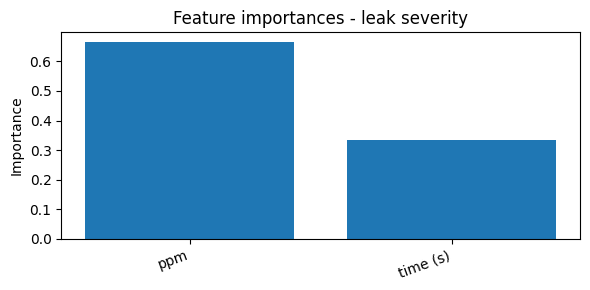

,feature,importance
0,ppm,0.665173
1,time (s),0.334827


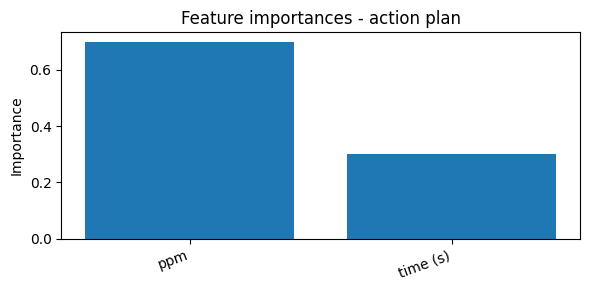

,feature,importance
0,ppm,0.69809
1,time (s),0.30191


In [18]:
for target in TARGET_COLUMNS:
    model = trained_models[target]
    feature_cols = selected_feature_sets[target]
    importances = model.feature_importances_

    fi_df = (
        pd.DataFrame({
            "feature": feature_cols,
            "importance": importances
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    plt.figure(figsize=(6, 3))
    plt.bar(fi_df["feature"], fi_df["importance"])
    plt.title(f"Feature importances - {target}")
    plt.ylabel("Importance")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    display(fi_df)

## 13) Confusion matrices

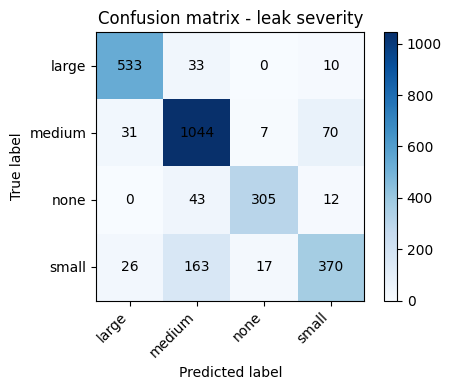

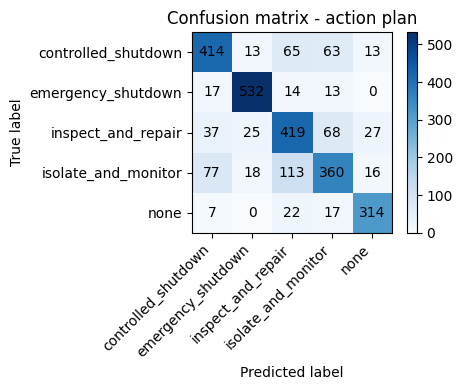

In [19]:
for target in TARGET_COLUMNS:
    model = trained_models[target]
    feature_cols = selected_feature_sets[target]
    X_test_target = df.loc[test_idx, feature_cols]
    y_true_enc = Y_test[target].values
    y_pred_enc = np.asarray(model.predict(X_test_target)).astype(int)

    cm = confusion_matrix(y_true_enc, y_pred_enc)
    class_names = label_encoders[target].classes_

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"Confusion matrix - {target}")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

## 14) Save the retrained single-sensor bundle

In [20]:
model_bundle = {
    "models": trained_models,
    "label_encoders": label_encoders,
    "feature_columns": FEATURE_COLUMNS,
    "raw_sensor_columns": RAW_SENSOR_COLUMNS,
    "target_columns": TARGET_COLUMNS,
    "selected_feature_sets": selected_feature_sets,
    "search_results": search_results,
    "evaluation_results": evaluation_results,
}

joblib.dump(model_bundle, OUTPUT_MODEL_FILE)
print(f"Saved trained bundle to: {OUTPUT_MODEL_FILE}")

Saved trained bundle to: hydrogen_leakage_prediction_model_single_sensor.pkl


## 15) Inference on new single-sensor data

In [21]:
bundle = joblib.load(OUTPUT_MODEL_FILE)

models = bundle["models"]
label_encoders = bundle["label_encoders"]
selected_feature_sets = bundle["selected_feature_sets"]
target_columns = bundle["target_columns"]

new_row = {
    "time (s)": 120,
    "ppm": 18.5
}

predictions = {}

for target in target_columns:
    feature_cols = selected_feature_sets[target]
    new_data = pd.DataFrame([{col: new_row[col] for col in feature_cols}])

    pred_encoded = np.asarray(models[target].predict(new_data)).astype(int)[0]
    pred_label = label_encoders[target].inverse_transform([pred_encoded])[0]
    predictions[target] = pred_label

print("Decoded predictions:")
print(predictions)

Decoded predictions:
{'leak severity': 'medium', 'action plan': 'inspect_and_repair'}
